In [1]:
'''
Process the XRD data for the quaternary samples.
'''
import numpy as np
import matplotlib.pyplot as plt
from pyhtp.xrd import XrdDatabase, ICSD
from pyhtp.typing import SampleInfo, AngleRange
from pyhtp.quaternary import scatter_quaternary


In [2]:
icsd = ICSD(file_dir='data/GSST ICSD')
sample2 = SampleInfo(
    name='GSTSe-2', element=['Se', 'Sb', 'Ge', 'Te'],
    angle_range=AngleRange(28, 52), temperature=300,
    film_thickness=[12.4, 7.6, 12.4, 7.6])
db2 = XrdDatabase(file_dir='data/GSTSe_XRD/GSTSe-2-300', info=sample2)
sample1 = SampleInfo(
    name='GSTSe-2', element=['Se', 'Sb', 'Ge', 'Te'],
    angle_range=AngleRange(28, 52), temperature=350,
    film_thickness=[12.4, 7.6, 12.4, 7.6])
db1 = XrdDatabase(file_dir='data/GSTSe_XRD/GSTSe-2-350', info=sample1)


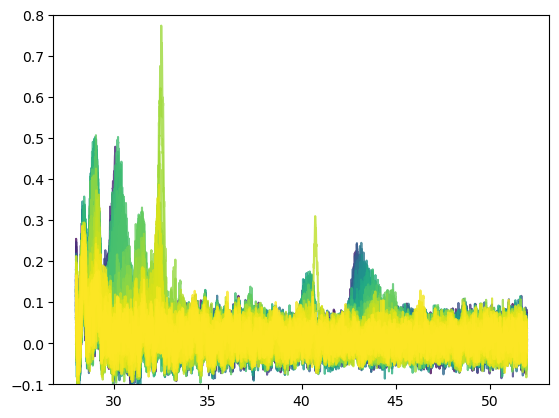

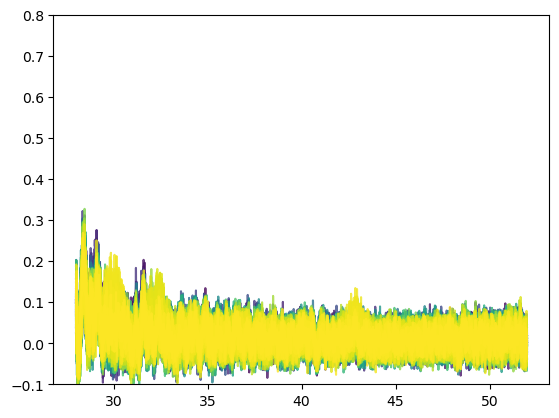

In [44]:
fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()
db1.subtract_baseline(lam=500).plot(ax=ax1)
db2.subtract_baseline(lam=500).plot(ax=ax2)
ax1.set_ylim(-0.1, 0.8)
ax2.set_ylim(-0.1, 0.8)
fig1.savefig('figure/GSST/GSTSe-2-350.png', dpi=600)
fig2.savefig('figure/GSST/GSTSe-2-300.png', dpi=600)

In [15]:
db = db1.subtract_baseline(lam=500).smooth(window=101, factor=0.6)


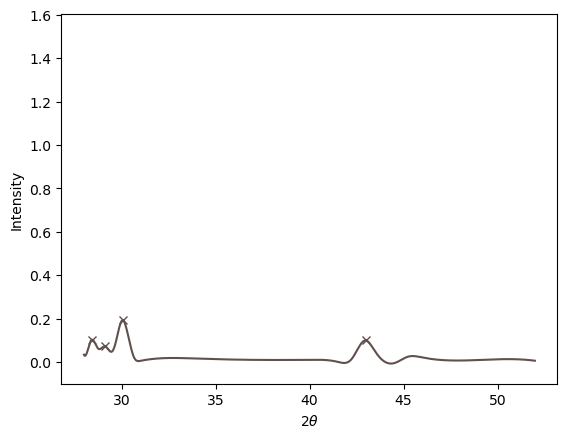

In [18]:
fig, ax = plt.subplots()
db.data[0].plot(ax=ax, color='#61504D', if_peak=True, height=0.05)
fig.patch.set_alpha(0)
ax.set_ylim(-0.1, 1.6035797831778071)
fig.savefig('figure/GSST/GSTSe-2-350-0-sm.png', dpi=600, transparent=True)

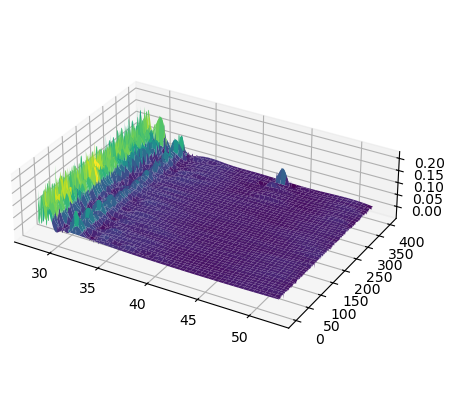

In [29]:
db.plot_surf()
plt.savefig('figure/GSST/GSTSe-2-300_surf.png', dpi=600)

In [22]:
print(icsd.data[icsd.index(icsd_code=40016)[0]])

IcsdData(name='Se_CollCode40016.cif', two_theta=array([23.89543103, 30.16547734, 42.02448752, 44.31973343, 46.12000119,
       48.91750101, 52.59562406, 56.45283447, 57.04196203, 62.16612774,
       62.7218317 , 66.42158282, 69.49462255, 72.81355593, 76.78673071,
       77.89122639, 78.3946314 , 79.69618012, 83.1685029 , 88.29564465]), intensity=array([5.07627576e+01, 1.00000000e+02, 1.54071929e+01, 3.40064200e+01,
       2.69138989e+01, 2.54330841e+00, 2.39820893e+01, 6.99000293e+00,
       1.41503866e+01, 6.79897659e+00, 1.40130465e+01, 1.84175692e+01,
       6.28571877e+00, 5.95154375e+00, 1.70702936e-02, 1.28373056e+00,
       4.51297401e+00, 7.70241973e+00, 5.45690520e+00, 6.14406268e+00]), hkl=[MillerIndice(h=1, k=0, l=0), MillerIndice(h=1, k=0, l=1), MillerIndice(h=2, k=-1, l=0), MillerIndice(h=1, k=0, l=2), MillerIndice(h=2, k=-1, l=1), MillerIndice(h=2, k=0, l=0), MillerIndice(h=2, k=0, l=1), MillerIndice(h=0, k=0, l=3), MillerIndice(h=2, k=-1, l=2), MillerIndice(h=1, k=0, l=3

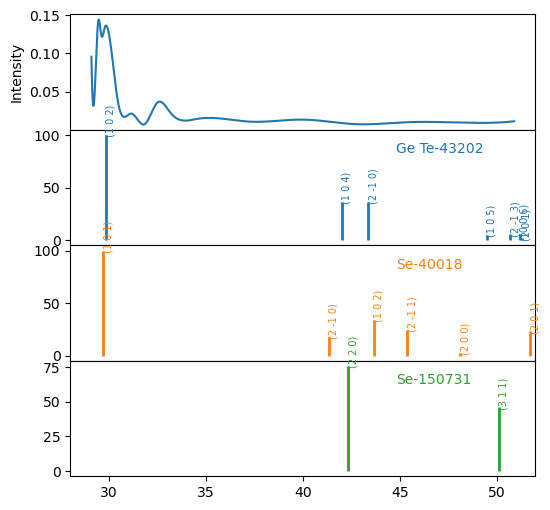

In [27]:
db.data[20].plot_with_icsd(icsd, number=3)

In [5]:
HEIGHT = 0.02
c_peaks = db.characteristic_peak(height=HEIGHT)
print([round(peak, 2) for peak in c_peaks])
label = db.classify((5, 20), height=HEIGHT, full_run=True, verbose=0)
print(np.unique(label, return_counts=True))

[28.42, 29.07, 30.23, 31.93, 34.44, 36.95, 40.32, 42.73, 43.69, 45.35, 50.63]
Classification with 5 clusters, silhouette score: 0.33
Classification with 6 clusters, silhouette score: 0.32
Classification with 7 clusters, silhouette score: 0.30
Classification with 8 clusters, silhouette score: 0.28
Classification with 9 clusters, silhouette score: 0.29
Classification with 10 clusters, silhouette score: 0.29
Classification with 11 clusters, silhouette score: 0.25
Classification with 12 clusters, silhouette score: 0.27
Classification with 13 clusters, silhouette score: 0.25
Classification with 14 clusters, silhouette score: 0.25
Classification with 15 clusters, silhouette score: 0.25
Classification with 16 clusters, silhouette score: 0.25
Classification with 17 clusters, silhouette score: 0.24
Classification with 18 clusters, silhouette score: 0.24
Classification with 19 clusters, silhouette score: 0.24
Finish with 0 clusters
(array([0, 1, 2, 3, 4]), array([114, 157, 111,   7,  11], dtype=

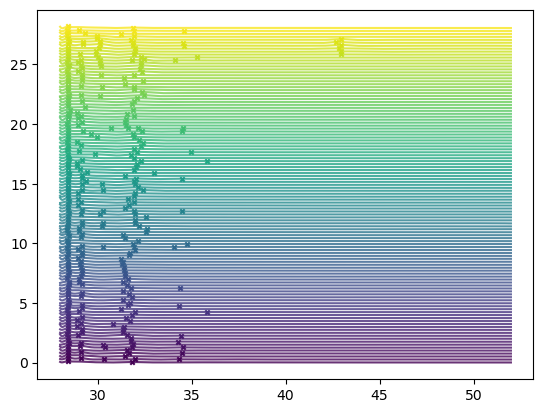

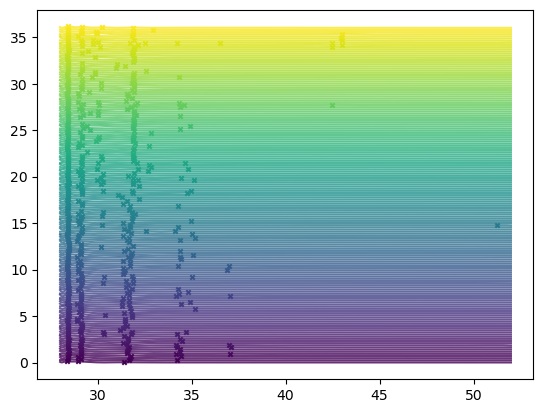

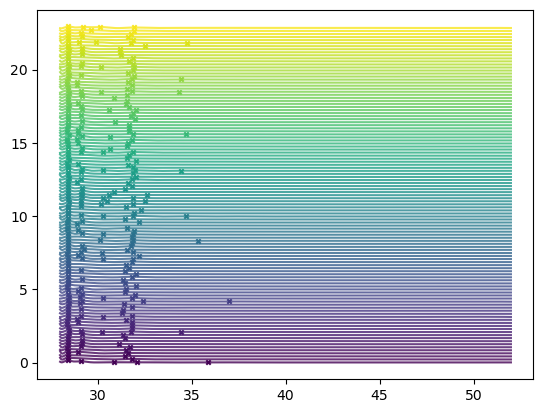

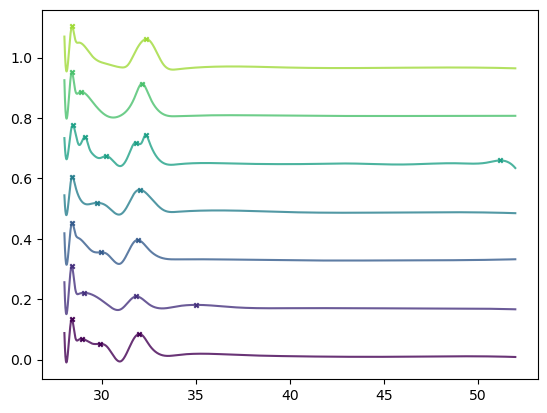

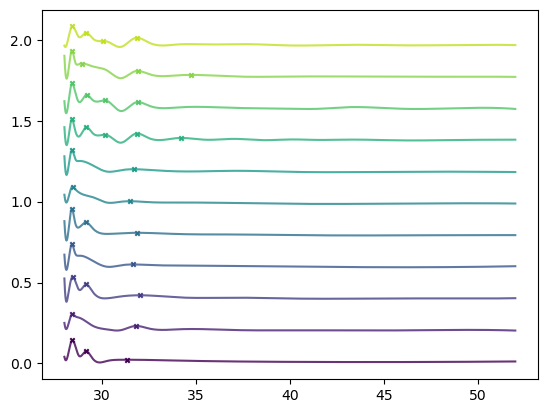

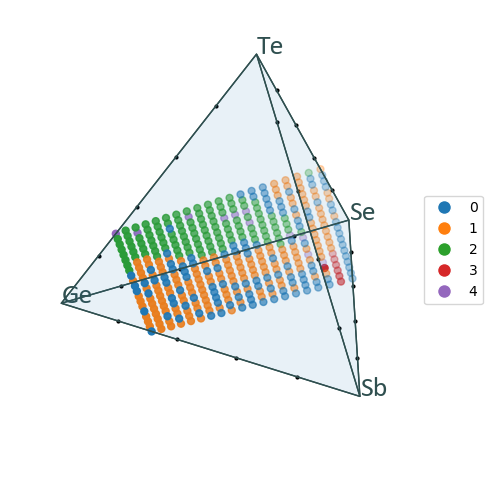

In [30]:
for i in range(len(np.unique(label))):
    db.plot(index=np.where(label == i)[0].tolist(), style='stack', height=HEIGHT)
scatter_quaternary(
    value=label, label=('Ge', 'Sb', 'Se', 'Te'),
    database=db, ticknum=5, path_type='snakelike')